In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")




In [9]:
from langchain.chat_models import init_chat_model
model = init_chat_model("google_genai:gemini-2.5-flash-lite")
response = model.invoke("What is the capital of France?")
response.content


'The capital of France is **Paris**.'

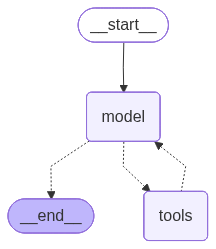

In [12]:
from langchain.agents import create_agent

def get_weather(city:str) -> str:
    """A mock function to get the current weather for a given city."""
    return f"The current weather in {city} is sunny with a temperature of 25°C."

agent = create_agent(
    model="google_genai:gemini-2.5-flash-lite",
    tools=[get_weather],
    system_prompt="You are a helpful assistant that can answer questions and perform tasks for the user.",
)

agent

In [14]:
agent.invoke({"messages":[{"role":"user","content":"What's the weather like in New York?"}]})

{'messages': [HumanMessage(content="What's the weather like in New York?", additional_kwargs={}, response_metadata={}, id='39ec2024-7046-48ff-be33-651620d9379e'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'get_weather', 'arguments': '{"city": "New York"}'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019df971-308a-7fc1-bc69-01ce69ab9e1e-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'New York'}, 'id': 'eadcb4db-078b-4929-a4c6-9894019f1f56', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 16, 'total_tokens': 88, 'input_token_details': {'cache_read': 0}}),
  ToolMessage(content='The current weather in New York is sunny with a temperature of 25°C.', name='get_weather', id='a548ea56-6cf9-4716-9b73-2df4a68ac18e', tool_call_id='eadcb4db-078b-4929-a4c6-9894019f1f56'),
  AIMessage(content='The curren

In [16]:
model.invoke("Write me 200 words paragharh on AI")


AIMessage(content='Artificial Intelligence (AI) is a transformative field focused on creating systems that can perform tasks typically requiring human intelligence. This encompasses a broad spectrum of capabilities, including learning, problem-solving, perception, and decision-making. AI is not a monolithic entity but rather a collection of diverse technologies, such as machine learning, deep learning, natural language processing, and computer vision. Machine learning, in particular, allows systems to learn from data without explicit programming, identifying patterns and making predictions. Deep learning, a subset of machine learning, utilizes artificial neural networks with multiple layers to process complex information, powering advancements in areas like image recognition and speech synthesis. Natural language processing enables computers to understand, interpret, and generate human language, facilitating applications like chatbots and translation services. Computer vision allows AI

In [18]:
for chunks in model.stream("Write me 200 words paragharh on AI"):
    print(chunks.text, end="|", flush=True)

Artificial intelligence| (AI) is rapidly transforming our world, ushering in an era of unprecedented| technological advancement. At its core, AI refers to the simulation of human intelligence in machines, enabling them to learn, reason, problem-solve, and perceive their environment. This encompasses a broad spectrum of technologies, from machine learning algorithms that allow| systems to improve with experience, to natural language processing that enables computers to understand and generate human language.

The applications of AI are vast and ever-expanding. In healthcare, AI is revolutionizing diagnostics and drug discovery. In finance, it'|s optimizing trading strategies and detecting fraud. The automotive industry is witnessing the rise of autonomous vehicles powered by AI. Beyond these, AI is enhancing customer service through chatbots, personalizing entertainment, and even assisting in scientific research. While the potential benefits are immense, ethical| considerations surround

In [19]:
for chunk in model.stream("Why do parrots have colourful feathers?"):
    print(chunk.text, end="|", flush=True)

Parrots have colorful feathers for| a variety of fascinating reasons, and it's not just for show! The| vibrant hues play crucial roles in their survival and social lives. Here are the main reasons:

**1. Communication and Social Signaling:**

* **Species Recognition:** The specific patterns and colors of a parrot's plumage help them identify members| of their own species. In dense rainforests where visibility can be limited, these visual cues are vital for finding mates and forming flocks.
* **Mate Attraction and Selection:** Brighter, more vibrant colors often indicate a healthier and more desirable| mate. During courtship displays, parrots may puff up their feathers, flash specific colors, and engage in elaborate movements to showcase their attractiveness.
* **Social Status and Dominance:** In some parrot species, the intensity or specific arrangement of colors can signal| social rank within a flock. Dominant individuals might have brighter plumage or specific markings.
* **Emotional

In [21]:
responses = model.batch([
    "What is the capital of France?",
    "How do airplanes fly?",
    "What is the largest mammal?",
    "Who won the World Cup in 2018?"
],
config={
    "max_concurrency": 2,  # Limit to 2 concurrent requests
})

for response in responses:
    print(response)

content='The capital of France is **Paris**.' additional_kwargs={} response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'} id='lc_run--019df986-3992-7dd2-8fc2-3fce7a1787fb-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 8, 'output_tokens': 8, 'total_tokens': 16, 'input_token_details': {'cache_read': 0}}
content='Airplanes fly due to a combination of **physics principles**, primarily related to **lift, thrust, drag, and weight**. Here\'s a breakdown of how it all works:\n\n**1. The Four Forces of Flight:**\n\nImagine an airplane in flight. Four main forces are acting on it:\n\n*   **Lift:** The upward force that counteracts gravity.\n*   **Weight:** The downward force due to gravity pulling the airplane towards the Earth.\n*   **Thrust:** The forward force generated by the engines that propels the airplane through the air.\n*   **Drag:** The backward force that opposes the airplane\